# Практическое занятие 5. Классификация частичных разрядов по PRPD-признакам

Цель занятия - научиться строить диагностическую классификацию
состояния изоляции по признакам частичных разрядов и сравнить
несколько базовых классификаторов.

Частичный разряд - локальный электрический разряд, который
возникает в части изоляционной системы и не полностью перекрывает
промежуток между электродами. PRPD (Phase Resolved Partial
Discharge) - фазово-разрешенное представление частичных разрядов,
связывающее импульсы с фазой питающего напряжения.

**Задача студента.** Нужно выбрать безопасные PRPD-признаки,
обучить несколько классификаторов, сравнить метрики и объяснить,
какие диагностические ошибки наиболее существенны. Основной
результат - корректная интерпретация графиков, матрицы ошибок и
антипримеров утечки данных.

## Инициализация среды выполнения

Ячейка ниже обеспечивает запуск блокнота в Google Colab и в
локальном Jupyter Notebook. Если проект уже открыт локально,
повторное клонирование не выполняется.

In [1]:
# COLAB_BOOTSTRAP_APPailab
from pathlib import Path
import os
import sys

REQUIRED_PROCESSED_FILES = ['practice_05_partial_discharge_features.csv', 'practice_05_partial_discharge_diagnostics.csv', 'practice_04_06_dataset_catalog.csv', 'practice_04_06_dataset_assignments.csv']
PROJECT_REPOSITORY_URL = "https://github.com/Alexflex/appailab.git"

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-colab.txt").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is None:
    try:
        import google.colab  # type: ignore
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

    if IN_COLAB:
        workdir = Path("/content/appailab")
        if not workdir.exists():
            !git clone -q {PROJECT_REPOSITORY_URL} {workdir}
        project_root = workdir
        os.chdir(project_root)
        !pip install -q -r requirements-colab.txt
    else:
        raise FileNotFoundError(
            "Не найден корень проекта. Откройте блокнот из репозитория appailab "
            "или выполните git clone перед запуском."
        )

sys.path.insert(0, str(project_root / "src"))
missing_files = [
    name for name in REQUIRED_PROCESSED_FILES
    if not (project_root / "data" / "processed" / name).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Не найдены подготовленные CSV: " + ", ".join(missing_files)
        + ". Выполните python scripts/generate_datasets.py."
    )

print(f"Корень проекта: {project_root}")
print("Проверенные CSV:", ", ".join(REQUIRED_PROCESSED_FILES))

Корень проекта: /mnt/f/projects/appai_lab
Проверенные CSV: practice_05_partial_discharge_features.csv, practice_05_partial_discharge_diagnostics.csv, practice_04_06_dataset_catalog.csv, practice_04_06_dataset_assignments.csv


In [2]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = project_root / "data" / "processed"
CATALOG_04_06_FILE = DATA_DIR / "practice_04_06_dataset_catalog.csv"
ASSIGNMENTS_04_06_FILE = DATA_DIR / "practice_04_06_dataset_assignments.csv"
RANDOM_STATE = 20260507

## Источники и проверка актуальности

Для занятий 4-6 используются базовые локальные учебные CSV, поэтому
выполнение блокнота не зависит от загрузки внешних архивов. Открытые
источники ниже используются как научно-методические ориентиры для
расширенных заданий и проверки переносимости постановки.

1. NASA C-MAPSS Aircraft Engine Simulator Data - открытый набор
   траекторий деградации авиационных двигателей. Применение:
   временная регрессия, риск утечки между соседними точками,
   кластеризация режимов деградации. URL:
   https://data.nasa.gov/dataset/groups/c-mapss-aircraft-engine-simulator-data
2. Mendeley Data `Partial Discharge Signals in Insulated Power
   Cables with Time-of-Arrival Annotations` - временные сигналы
   частичных разрядов с аннотациями времени прихода импульсов.
   Применение: извлечение PRPD-признаков перед классификацией. URL:
   https://data.mendeley.com/datasets/3mdgxv6zt7
3. UCI `AI4I 2020 Predictive Maintenance Dataset` - промышленно
   мотивированный набор для предиктивного обслуживания. Применение:
   отделение сенсорных признаков от служебных кодов и признаков
   отказов перед кластеризацией. URL:
   https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
4. NASA Prognostics Center of Excellence Data Repository - реестр
   наборов для диагностики и прогнозирования технического состояния.
   Применение: расширение задач кластеризации и анализа временных
   сценариев. URL:
   https://www.nasa.gov/content/prognostics-center-of-excellence-data-set-repository

Проверка ссылок выполнена 2026-05-15. Перед использованием полного
внешнего источника в самостоятельной работе необходимо повторно
проверить карточку набора данных, лицензию, размер архива и формат
файлов.

## Теоретический блок

Метод опорных векторов (Support Vector Machine, SVM) строит
разделяющую поверхность между классами. Для линейного SVM эта
поверхность является гиперплоскостью. Для SVM с радиальной
базисной функцией (Radial Basis Function, RBF) граница может быть
нелинейной.

Логистическая регрессия (Logistic Regression) служит простой
базовой моделью классификации. Случайный лес и дерево решений
позволяют получить более гибкую нелинейную границу, но требуют
контроля переобучения.

Для многоклассовой диагностики важны не только accuracy, но и
macro-precision, macro-recall и macro-F1. Приставка macro означает,
что метрика сначала считается по каждому классу, а затем
усредняется без учета размера класса.

## Последовательность работы

Pipeline занятия:

1. загрузить таблицу PRPD-признаков;
2. проверить классы и распределения признаков;
3. выбрать безопасные признаки без diagnostic-столбцов;
4. выполнить масштабирование признаков;
5. обучить несколько классификаторов;
6. сравнить accuracy и macro-F1;
7. разобрать матрицу ошибок;
8. проверить антипримеры: отсутствие масштабирования и утечку
   `risk_score`.

In [3]:
FEATURES_FILE = DATA_DIR / "practice_05_partial_discharge_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "practice_05_partial_discharge_diagnostics.csv"

df = pd.read_csv(FEATURES_FILE)
diagnostics_df = pd.read_csv(DIAGNOSTICS_FILE)
full_df = df.merge(diagnostics_df, on="sample_id", validate="one_to_one")

display(df.head())
print("Размер feature-таблицы:", df.shape)
print("Классы:", sorted(df["defect_class"].unique()))

,sample_id,profile_id,voltage_kv,frequency_hz,phase_mean_deg,phase_std_deg,pulse_count,mean_charge_pc,max_charge_pc,charge_iqr_pc,repetition_rate_hz,positive_negative_ratio,waveform_rise_ns,waveform_width_ns,prpd_entropy,defect_class
0,1,3,20.397,50.0,273.133,36.876,28,124.745,279.785,38.652,13.613,1.2114,45.129,215.033,0.62652,internal
1,2,5,12.175,50.0,160.832,94.291,7,4.531,8.809,1.324,2.486,1.2702,21.661,115.778,0.26483,no_pd
2,3,8,6.130,50.0,150.155,65.063,38,48.470,99.122,25.782,19.986,1.4766,42.277,152.701,0.54980,surface
3,4,8,11.073,60.0,244.695,107.603,4,10.541,13.516,4.433,1.685,1.3276,19.782,89.182,0.27084,no_pd
4,5,6,19.976,50.0,63.716,34.493,35,217.788,373.173,112.810,18.231,0.8527,54.238,191.714,0.76306,internal


Размер feature-таблицы: (640, 16)
Классы: ['corona', 'internal', 'no_pd', 'surface']


## Схематическая PRPD-диаграмма

PRPD-диаграмма показывает, в каких фазовых областях появляются
импульсы и какова их амплитуда. В учебном наборе используются уже
извлеченные признаки, но диаграмма ниже помогает связать
табличные признаки с исходной физической картиной.

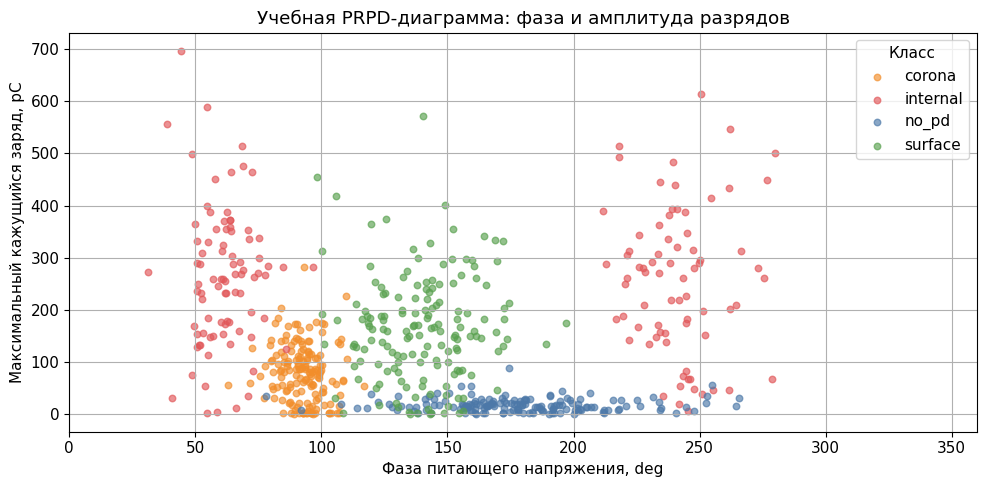

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_by_class = {
    "no_pd": "#4c78a8",
    "corona": "#f28e2b",
    "surface": "#59a14f",
    "internal": "#e15759",
}
for label, group in df.groupby("defect_class"):
    ax.scatter(
        group["phase_mean_deg"],
        group["max_charge_pc"],
        s=22,
        alpha=0.65,
        label=label,
        color=colors_by_class[label],
    )
ax.set_xlim(0, 360)
ax.set_xlabel("Фаза питающего напряжения, deg")
ax.set_ylabel("Максимальный кажущийся заряд, pC")
ax.set_title("Учебная PRPD-диаграмма: фаза и амплитуда разрядов")
ax.legend(title="Класс")
plt.tight_layout()
plt.show()

## Структура данных

В feature-CSV находится целевая переменная `defect_class`.
Остальные столбцы описывают статистические признаки PRPD:
фазовое положение, разброс фазы, число импульсов, кажущийся заряд,
повторяемость и параметры формы импульса.

В diagnostics-CSV находятся производные диагностические величины:
числовой код класса, бинарный признак наличия разряда и риск-оценка.
Эти столбцы не должны использоваться как входные признаки базовой
модели.

Первый график ниже показывает баланс классов, второй - разделение
классов по двум физически интерпретируемым признакам: фазе и
среднему кажущемуся заряду. Если классы хорошо разделены уже на
таком графике, высокая точность модели ожидаема и не должна
восприниматься как универсальная гарантия для реальных данных.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,640.0,NaN,NaN,NaN,320.5,184.896367,1.0,160.75,320.5,480.25,640.0
profile_id,640.0,NaN,NaN,NaN,4.442188,2.29235,1.0,2.0,4.0,6.0,8.0
voltage_kv,640.0,NaN,NaN,NaN,15.225473,5.18689,6.013,10.65175,15.4295,19.72475,23.996
frequency_hz,640.0,NaN,NaN,NaN,52.046875,4.037887,50.0,50.0,50.0,50.0,60.0
phase_mean_deg,640.0,NaN,NaN,NaN,138.788936,57.929189,31.024,91.95725,134.7055,174.97625,279.96
phase_std_deg,640.0,NaN,NaN,NaN,50.64837,28.220605,17.132,26.43175,42.482,67.16425,115.0
pulse_count,640.0,NaN,NaN,NaN,26.209375,13.029757,1.0,15.0,25.0,36.0,61.0
mean_charge_pc,640.0,NaN,NaN,NaN,67.992505,64.571679,0.5,11.07275,51.981,106.9295,317.223
max_charge_pc,640.0,NaN,NaN,NaN,130.426738,127.633146,0.644,21.4545,94.589,194.75125,697.264
charge_iqr_pc,640.0,NaN,NaN,NaN,24.471864,24.29977,0.1,4.3515,17.1695,36.798,121.467


,count
defect_class,
corona,160
internal,160
no_pd,160
surface,160


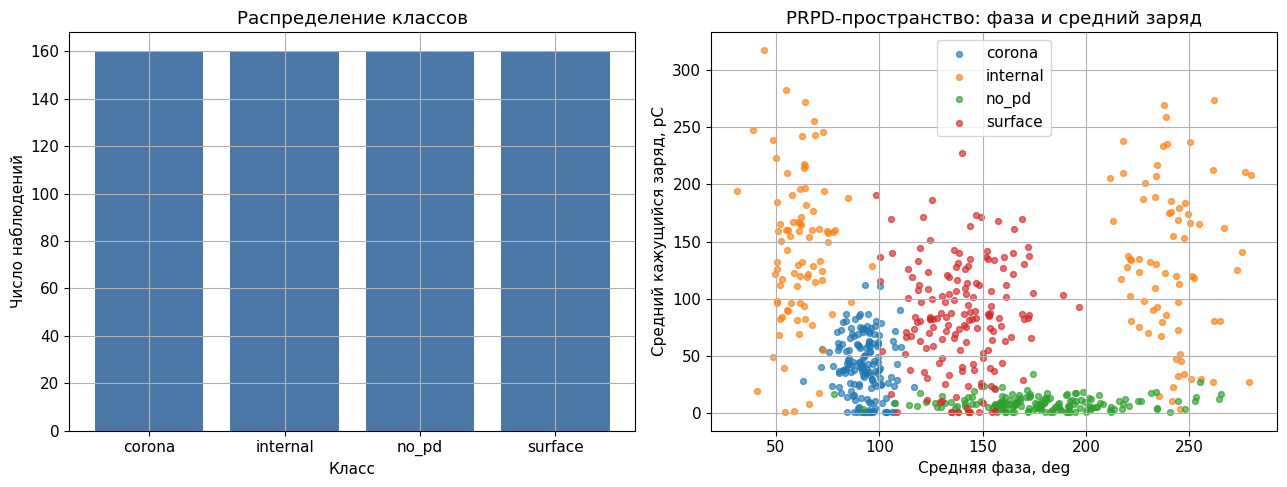

In [5]:
display(df.describe(include="all").T)
class_counts = df["defect_class"].value_counts().sort_index()
display(class_counts.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(class_counts.index, class_counts.values, color="#4c78a8")
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Число наблюдений")

for label, group in df.groupby("defect_class"):
    axes[1].scatter(group["phase_mean_deg"], group["mean_charge_pc"], s=18, alpha=0.65, label=label)
axes[1].set_title("PRPD-пространство: фаза и средний заряд")
axes[1].set_xlabel("Средняя фаза, deg")
axes[1].set_ylabel("Средний кажущийся заряд, pC")
axes[1].legend()
plt.tight_layout()
plt.show()

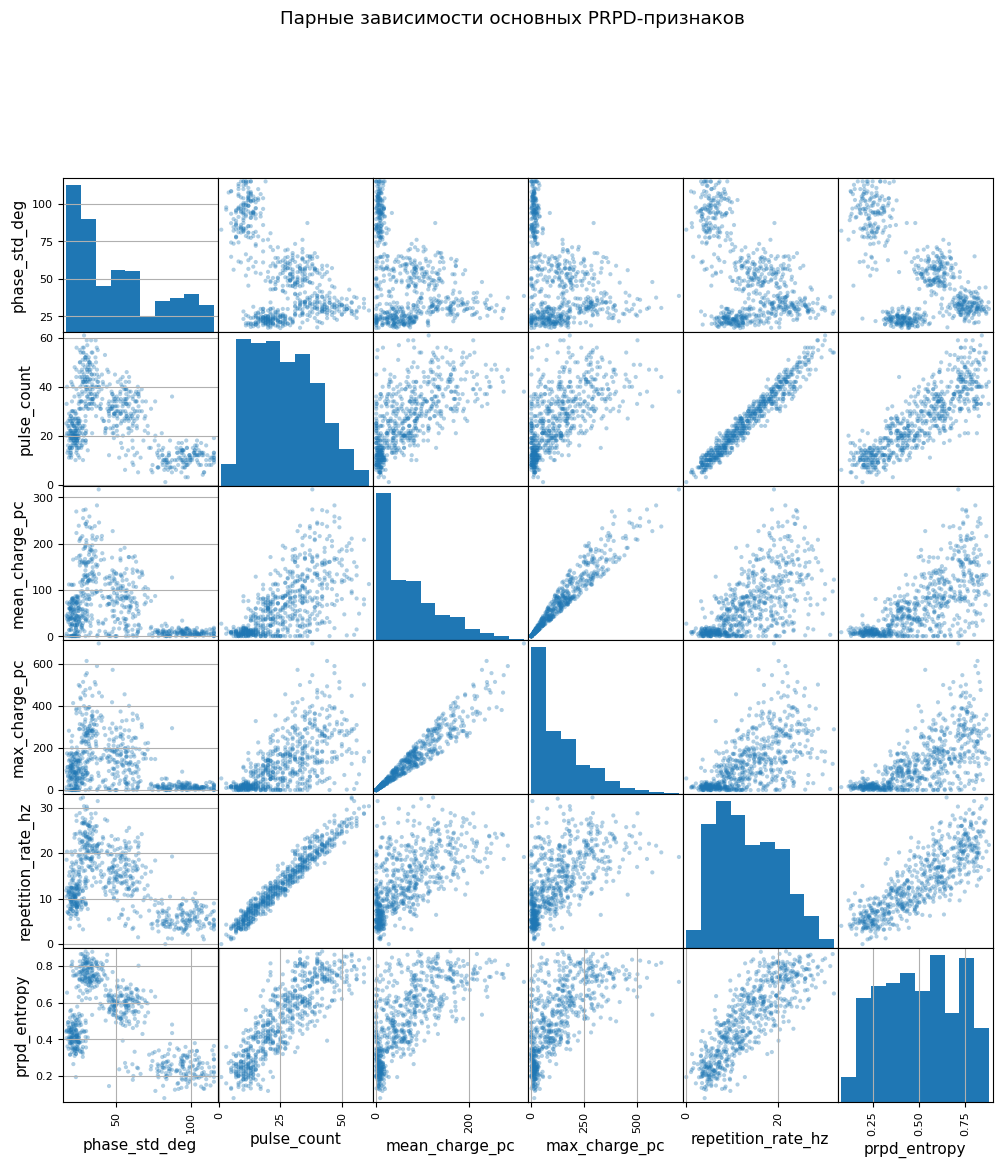

In [6]:
corr_features = [
    "phase_std_deg",
    "pulse_count",
    "mean_charge_pc",
    "max_charge_pc",
    "repetition_rate_hz",
    "prpd_entropy",
]
pd.plotting.scatter_matrix(df[corr_features], figsize=(12, 12), diagonal="hist", alpha=0.35)
plt.suptitle("Парные зависимости основных PRPD-признаков", y=1.02)
plt.show()

## Выбор признаков и подготовка выборок

In [7]:
pd_features = ['voltage_kv', 'frequency_hz', 'phase_mean_deg', 'phase_std_deg', 'pulse_count', 'mean_charge_pc', 'max_charge_pc', 'charge_iqr_pc', 'repetition_rate_hz', 'positive_negative_ratio', 'waveform_rise_ns', 'waveform_width_ns', 'prpd_entropy']

target_column = "defect_class"
forbidden_columns = {"defect_class", "defect_code", "risk_score", "high_risk", "has_partial_discharge"}
leaked = forbidden_columns.intersection(pd_features)
if leaked:
    raise ValueError(f"Обнаружена утечка данных: {sorted(leaked)}")

X = df[pd_features]
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
print("Train:", X_train.shape, "Test:", X_test.shape)
display(y_test.value_counts().sort_index().to_frame("test_count"))

Train: (480, 13) Test: (160, 13)


,test_count
defect_class,
corona,40
internal,40
no_pd,40
surface,40


In [8]:
scaler_explanation = 'StandardScaler нужен, потому что SVM использует расстояния между объектами, а признаки измеряются в разных единицах: градусах, пикокулонах, наносекундах и герцах.'
print(scaler_explanation)

StandardScaler нужен, потому что SVM использует расстояния между объектами, а признаки измеряются в разных единицах: градусах, пикокулонах, наносекундах и герцах.


## Обучение классификаторов

In [9]:
classifiers = {
    "logistic_regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "decision_tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "svm_linear": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="linear", C=1.0, class_weight="balanced")),
        ]
    ),
    "svm_rbf": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced")),
        ]
    ),
}

predictions = {}
metric_rows = []
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    metric_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision_macro": precision_score(y_test, pred, average="macro"),
            "recall_macro": recall_score(y_test, pred, average="macro"),
            "f1_macro": f1_score(y_test, pred, average="macro"),
        }
    )

metrics_df = pd.DataFrame(metric_rows).sort_values("f1_macro", ascending=False)
display(metrics_df)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,logistic_regression,1.00000,1.000000,1.00000,1.000000
2,random_forest,1.00000,1.000000,1.00000,1.000000
3,svm_linear,1.00000,1.000000,1.00000,1.000000
4,svm_rbf,1.00000,1.000000,1.00000,1.000000
1,decision_tree,0.99375,0.993902,0.99375,0.993749


In [10]:
best_classifier_interpretation = 'Для этой диагностической задачи рационально выбирать модель по macro-F1, потому что эта метрика учитывает качество по каждому классу, а не только общую долю правильных ответов.'
print(best_classifier_interpretation)

Для этой диагностической задачи рационально выбирать модель по macro-F1, потому что эта метрика учитывает качество по каждому классу, а не только общую долю правильных ответов.


## Сравнение balanced и imbalanced выборок

Accuracy может выглядеть высокой на несбалансированной выборке,
даже если редкий дефект распознается хуже. Поэтому дополнительно
сравним модель на исходной сбалансированной обучающей выборке и
на искусственно несбалансированной подвыборке.

In [11]:
train_df_for_imbalance = df.loc[X_train.index].copy()
imbalanced_parts = []
for label, group in train_df_for_imbalance.groupby("defect_class"):
    keep_count = len(group) if label == "no_pd" else max(18, len(group) // 3)
    imbalanced_parts.append(group.sample(n=keep_count, random_state=RANDOM_STATE))
imbalanced_train_df = pd.concat(imbalanced_parts, ignore_index=False)

balanced_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ]
)
imbalanced_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ]
)
balanced_model.fit(X_train, y_train)
imbalanced_model.fit(imbalanced_train_df[pd_features], imbalanced_train_df[target_column])
balanced_pred = balanced_model.predict(X_test)
imbalanced_pred = imbalanced_model.predict(X_test)
imbalance_metrics = pd.DataFrame(
    [
        {
            "training_set": "balanced",
            "accuracy": accuracy_score(y_test, balanced_pred),
            "macro_F1": f1_score(y_test, balanced_pred, average="macro"),
        },
        {
            "training_set": "artificially_imbalanced",
            "accuracy": accuracy_score(y_test, imbalanced_pred),
            "macro_F1": f1_score(y_test, imbalanced_pred, average="macro"),
        },
    ]
)
display(imbalance_metrics)

,training_set,accuracy,macro_F1
0,balanced,1.0,1.0
1,artificially_imbalanced,1.0,1.0


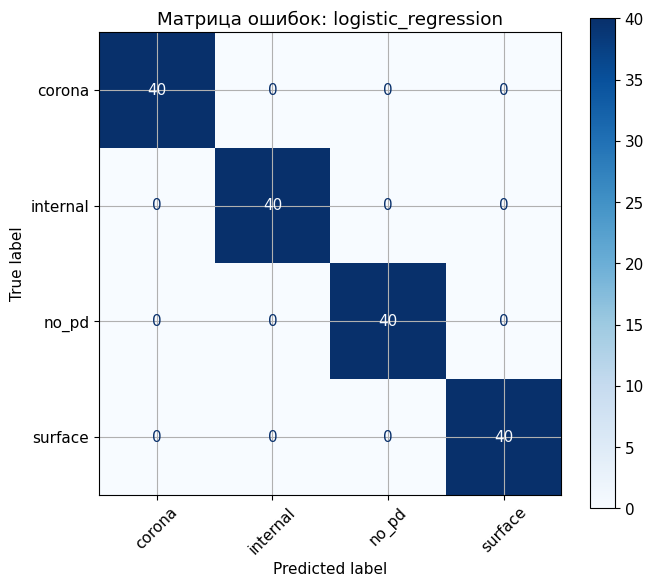

              precision    recall  f1-score   support

      corona      1.000     1.000     1.000        40
    internal      1.000     1.000     1.000        40
       no_pd      1.000     1.000     1.000        40
     surface      1.000     1.000     1.000        40

    accuracy                          1.000       160
   macro avg      1.000     1.000     1.000       160
weighted avg      1.000     1.000     1.000       160



In [12]:
best_model_name = metrics_df.iloc[0]["model"]
best_pred = predictions[best_model_name]
labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    labels=labels,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"Матрица ошибок: {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred, digits=3))

## Разбор диагностических ошибок

Матрица ошибок должна интерпретироваться не только формально, но
и инженерно. Ошибка между `corona` и `surface` имеет один смысл,
а пропуск класса `internal` может быть существенно опаснее,
поскольку внутренние дефекты часто связаны с объемом изоляции.

In [13]:
error_df = pd.DataFrame({"true": y_test, "predicted": best_pred})
error_df["is_error"] = error_df["true"] != error_df["predicted"]
error_summary = (
    error_df.groupby("true")
    .agg(test_count=("true", "size"), error_count=("is_error", "sum"))
    .assign(error_rate=lambda data: data["error_count"] / data["test_count"])
    .sort_values("error_rate", ascending=False)
)
display(error_summary)

,test_count,error_count,error_rate
true,,,
corona,40,0,0.0
internal,40,0,0.0
no_pd,40,0,0.0
surface,40,0,0.0


In [14]:
diagnostic_error_interpretation = 'В эталонном запуске классы почти не путаются; если ошибка появилась, необходимо указать истинный класс, предсказанный класс и возможную физическую причину близости PRPD-признаков.'
print(diagnostic_error_interpretation)

В эталонном запуске классы почти не путаются; если ошибка появилась, необходимо указать истинный класс, предсказанный класс и возможную физическую причину близости PRPD-признаков.


## Учебная граница SVM по двум признакам

Следующая схема не заменяет многомерную модель. Она нужна, чтобы
визуально показать идею SVM: алгоритм строит границу между
областями классов в пространстве признаков. Здесь используются
только `phase_mean_deg` и `mean_charge_pc`.

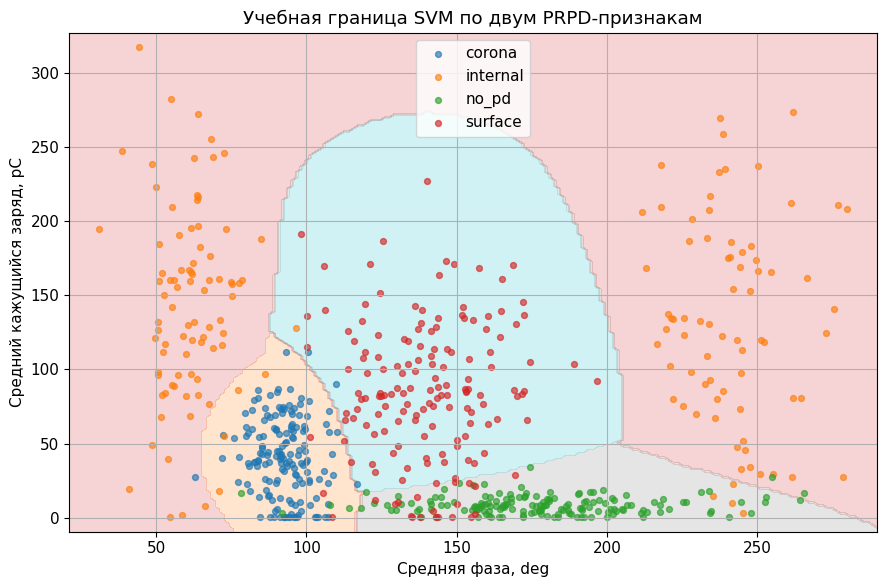

In [15]:
svm_2d_features = ["phase_mean_deg", "mean_charge_pc"]
svm_2d = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=3.0, gamma="scale")),
    ]
)
svm_2d.fit(X_train[svm_2d_features], y_train)
x_min, x_max = df["phase_mean_deg"].min() - 10, df["phase_mean_deg"].max() + 10
y_min, y_max = df["mean_charge_pc"].min() - 10, df["mean_charge_pc"].max() + 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 180), np.linspace(y_min, y_max, 180))
grid = pd.DataFrame(
    {
        "phase_mean_deg": xx.ravel(),
        "mean_charge_pc": yy.ravel(),
    }
)
zz = svm_2d.predict(grid).reshape(xx.shape)
label_to_int = {label: index for index, label in enumerate(sorted(y.unique()))}
zz_int = np.vectorize(label_to_int.get)(zz)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, zz_int, levels=len(label_to_int), alpha=0.20, cmap="tab10")
for label, group in df.groupby("defect_class"):
    ax.scatter(group["phase_mean_deg"], group["mean_charge_pc"], s=18, alpha=0.65, label=label)
ax.set_xlabel("Средняя фаза, deg")
ax.set_ylabel("Средний кажущийся заряд, pC")
ax.set_title("Учебная граница SVM по двум PRPD-признакам")
ax.legend()
plt.tight_layout()
plt.show()

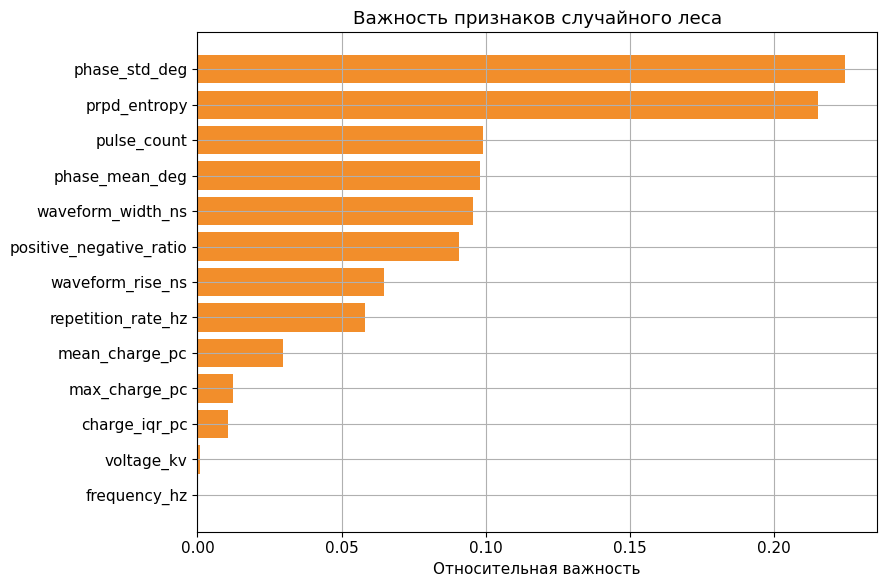

,feature,importance
3,phase_std_deg,0.224490
12,prpd_entropy,0.215375
4,pulse_count,0.099199
2,phase_mean_deg,0.098104
11,waveform_width_ns,0.095654
9,positive_negative_ratio,0.090619
10,waveform_rise_ns,0.064818
8,repetition_rate_hz,0.058139
5,mean_charge_pc,0.029781
6,max_charge_pc,0.012245


In [16]:
rf_model = classifiers["random_forest"]
importance_df = pd.DataFrame(
    {
        "feature": pd_features,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df["feature"], importance_df["importance"], color="#f28e2b")
ax.set_title("Важность признаков случайного леса")
ax.set_xlabel("Относительная важность")
plt.tight_layout()
plt.show()
display(importance_df.sort_values("importance", ascending=False))

## Антипример: SVM без масштабирования

SVM чувствителен к расстояниям. Если признаки с разными единицами
измерения не масштабировать, признаки с большими численными
диапазонами получают непропорционально высокий вклад.

In [17]:
svm_without_scaling = SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced")
svm_without_scaling.fit(X_train, y_train)
no_scaling_pred = svm_without_scaling.predict(X_test)
scaling_comparison = pd.DataFrame(
    [
        {
            "model": "svm_rbf_with_scaler",
            "accuracy": accuracy_score(y_test, predictions["svm_rbf"]),
            "macro_F1": f1_score(y_test, predictions["svm_rbf"], average="macro"),
        },
        {
            "model": "svm_rbf_without_scaler",
            "accuracy": accuracy_score(y_test, no_scaling_pred),
            "macro_F1": f1_score(y_test, no_scaling_pred, average="macro"),
        },
    ]
)
display(scaling_comparison)

,model,accuracy,macro_F1
0,svm_rbf_with_scaler,1.00000,1.000000
1,svm_rbf_without_scaler,0.98125,0.981244


## Демонстрация утечки данных

> **Внимание. АНТИПРИМЕР - НЕ ИСПОЛЬЗОВАТЬ КАК РАБОЧУЮ МОДЕЛЬ.**
> В следующей ячейке в признаки добавляется `risk_score`.
> Этот столбец рассчитан из скрытого правила генератора и
> частично кодирует диагностический класс. Его использование
> завышает качество модели и нарушает учебную постановку.

In [18]:
leakage_df = df.merge(diagnostics_df[["sample_id", "risk_score"]], on="sample_id", validate="one_to_one")
X_leak = leakage_df[pd_features + ["risk_score"]]
X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_leak,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
leakage_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
leakage_model.fit(X_train_leak, y_train_leak)
leakage_pred = leakage_model.predict(X_test_leak)
print("F1-macro строгой лучшей модели:", round(float(metrics_df.iloc[0]["f1_macro"]), 4))
print("F1-macro модели с утечкой:", round(f1_score(y_test_leak, leakage_pred, average="macro"), 4))

F1-macro строгой лучшей модели: 1.0
F1-macro модели с утечкой: 1.0


In [19]:
pd_leakage_explanation = 'risk_score является утечкой, потому что это производная диагностическая оценка, построенная с учетом скрытого правила разметки и близкая к целевому классу.'
print(pd_leakage_explanation)

risk_score является утечкой, потому что это производная диагностическая оценка, построенная с учетом скрытого правила разметки и близкая к целевому классу.


## Самостоятельный эксперимент

In [20]:
experiment_c = 3.0

experiment_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=experiment_c, gamma="scale", class_weight="balanced")),
    ]
)
experiment_model.fit(X_train, y_train)
experiment_pred = experiment_model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, experiment_pred), 4))
print("Recall macro:", round(recall_score(y_test, experiment_pred, average="macro"), 4))
print("F1 macro:", round(f1_score(y_test, experiment_pred, average="macro"), 4))

Accuracy: 1.0
Recall macro: 1.0
F1 macro: 1.0


## Реестр найденных наборов данных и развернутые задания

В этом разделе используется единый реестр открытых источников для
занятий 4-6. Реестр не загружает крупные архивы автоматически.
Его назначение - показать, как переносить базовую учебную
постановку на реальные или открытые исследовательские источники.

Для занятия 5 студент должен выбрать один источник
из таблицы ниже и описать, как на нем можно воспроизвести логику
базового блокнота: определить признаки, целевую переменную или
скрытую разметку, способ разбиения выборки, риск утечки данных и
ожидаемые визуализации.

In [21]:
dataset_catalog_04_06 = pd.read_csv(CATALOG_04_06_FILE)
dataset_assignments_04_06 = pd.read_csv(ASSIGNMENTS_04_06_FILE)

pd.set_option("display.max_colwidth", 120)
display(
    dataset_catalog_04_06[
        [
            "dataset_id",
            "name",
            "object",
            "lessons",
            "access",
            "risk_level",
            "implementation_status",
            "checked_at",
        ]
    ]
)

,dataset_id,name,object,lessons,access,risk_level,implementation_status,checked_at
0,nasa_cmapss,C-MAPSS Aircraft Engine Simulator Data,симулированные траектории деградации авиационного турбовентиляторного двигателя,"4,6",NASA Open Data Portal,средний,methodology_only,2026-05-15
1,mendeley_pd_cables_toa,Partial Discharge Signals in Insulated Power Cables with Time-of-Arrival Annotations,временные сигналы частичных разрядов в силовых кабелях,5,Mendeley Data,средний,methodology_only,2026-05-15
2,zenodo_pd_calibrator,Dataset for New Synthetic Partial Discharge Calibrator,сигналы калибратора частичных разрядов,5,Zenodo,низкий,methodology_only,2026-05-15
3,uci_ai4i_2020,AI4I 2020 Predictive Maintenance Dataset,"синтетические, но промышленно мотивированные режимы оборудования и отказы",6,UCI Machine Learning Repository,средний,methodology_only,2026-05-15
4,nasa_pcoe_adapt,NASA PCoE ADAPT Diagnostic Data,диагностические данные испытательного стенда электропитания ADAPT,6,NASA Prognostics Center of Excellence,высокий,methodology_only,2026-05-15


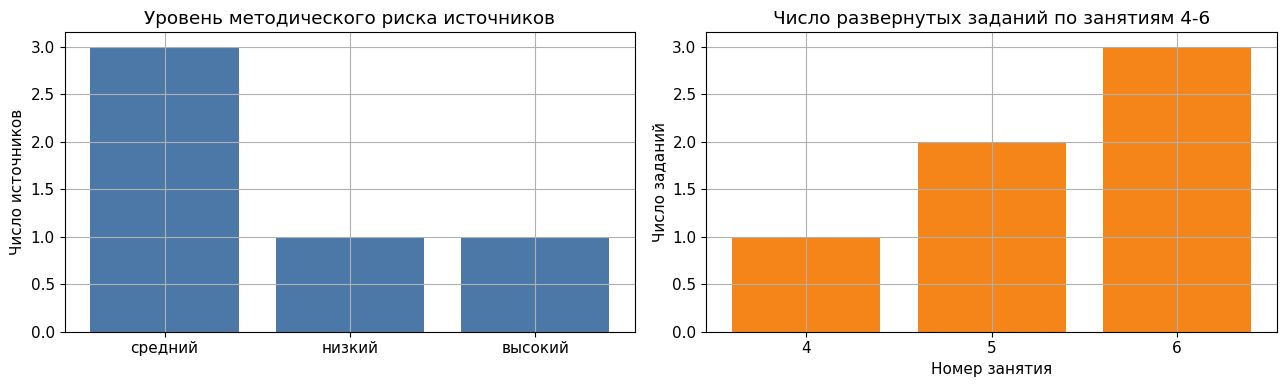

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

risk_counts = dataset_catalog_04_06["risk_level"].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color="#4c78a8")
axes[0].set_title("Уровень методического риска источников")
axes[0].set_ylabel("Число источников")

lesson_counts = (
    dataset_assignments_04_06["lesson"]
    .astype(str)
    .value_counts()
    .sort_index()
)
axes[1].bar(lesson_counts.index, lesson_counts.values, color="#f58518")
axes[1].set_title("Число развернутых заданий по занятиям 4-6")
axes[1].set_xlabel("Номер занятия")
axes[1].set_ylabel("Число заданий")

plt.tight_layout()
plt.show()

In [23]:
lesson_assignments = dataset_assignments_04_06[
    dataset_assignments_04_06["lesson"].astype(str) == "5"
].copy()

display(
    lesson_assignments[
        [
            "assignment_id",
            "assignment_title",
            "implementation_status",
            "dataset_structure",
            "theory_block",
            "practice_block",
            "recommended_visualizations",
            "expected_artifacts",
            "control_questions",
            "risk_note",
        ]
    ]
)

,assignment_id,assignment_title,implementation_status,dataset_structure,theory_block,practice_block,recommended_visualizations,expected_artifacts,control_questions,risk_note
2,mendeley_pd_cables_toa_lesson_5,Извлечение PRPD-признаков и классификация: Partial Discharge Signals in Insulated Power Cables with Time-of-Arrival ...,methodology_only,Объект: временные сигналы частичных разрядов в силовых кабелях. Формат: файлы сигналов и таблицы аннотаций. Доступ: ...,"Опишите переход от сырого временного сигнала к признакам частичных разрядов: амплитуда, энергия, число импульсов, фа...","Предложите минимальный набор признаков, целевую переменную для классификации и схему разделения измерительных опытов...",пример временного сигнала; гистограмма амплитуд; PRPD-диаграмма; матрица ошибок,"Краткий паспорт источника, таблица ролей столбцов, перечень рисков утечки данных, 2-3 рекомендуемые визуализации и в...","Что такое наблюдение: импульс, окно или опыт? Какие аннотации создают утечку? Почему нужно фиксировать частоту дискр...",нельзя случайно перемешивать импульсы одного измерительного опыта между train и test
3,zenodo_pd_calibrator_lesson_5,Извлечение PRPD-признаков и классификация: Dataset for New Synthetic Partial Discharge Calibrator,methodology_only,Объект: сигналы калибратора частичных разрядов. Формат: сигналы и сопроводительные таблицы. Доступ: Zenodo. Размер: ...,"Опишите переход от сырого временного сигнала к признакам частичных разрядов: амплитуда, энергия, число импульсов, фа...","Предложите минимальный набор признаков, целевую переменную для классификации и схему разделения измерительных опытов...",пример временного сигнала; гистограмма амплитуд; PRPD-диаграмма; матрица ошибок,"Краткий паспорт источника, таблица ролей столбцов, перечень рисков утечки данных, 2-3 рекомендуемые визуализации и в...","Что такое наблюдение: импульс, окно или опыт? Какие аннотации создают утечку? Почему нужно фиксировать частоту дискр...","источник ближе к метрологической проверке, чем к классификации реальных дефектов"


## Индивидуальное расширенное задание

Выберите один источник из таблицы выше и заполните в отчете
отдельный подраздел:

1. объект исследования и единица наблюдения;
2. какие столбцы являются измеряемыми признаками;
3. какая величина является целевой переменной или скрытой
   диагностической разметкой;
4. какие столбцы нельзя использовать как признаки из-за риска
   утечки данных;
5. какой способ разбиения выборки является корректным;
6. какие 2-3 графика нужно построить в первую очередь.

Если полный архив не скачивался, это нужно явно указать. В таком
случае результатом считается методически корректная постановка
расширенного задания, а не численное обучение модели.

## Мини-задание по открытому источнику

Mendeley Data `Partial Discharge Signals in Insulated Power
Cables with Time-of-Arrival Annotations` содержит более близкую к
реальной задаче форму данных: временные сигналы и аннотации
импульсов. Для расширения работы укажите:

1. какие признаки нужно извлечь из сырых сигналов перед
   классификацией;
2. зачем фиксировать частоту дискретизации;
3. чем PRPD-признаки отличаются от сырых временных отсчетов;
4. какие риски утечки появляются, если импульсы одного
   измерительного опыта случайно перемешать между train и test.

## Задание для отчета

1. Опишите физический смысл PRPD-представления.
2. Сравните логистическую регрессию, дерево решений, случайный лес
   и два варианта SVM.
3. Объясните, почему масштабирование признаков обязательно для SVM.
4. Проанализируйте матрицу ошибок: какие классы чаще путаются.
5. Укажите, почему `risk_score` является антипримером утечки.
6. Выполните мини-задание по открытому источнику Mendeley на
   уровне постановки задачи без скачивания архива.

Открытые источники для расширения: Mendeley Data `Partial
Discharge Signals in Insulated Power Cables with Time-of-Arrival
Annotations` и наборы PRPD-изображений частичных разрядов. Для
реальных сигналов необходимо отдельно описывать частоту
дискретизации, способ фильтрации и протокол аннотирования.